In [1]:
import cv2
import glob

In [2]:
#1
import cv2
import glob

files = glob.glob(r"S:\CV Assessment\Data\*.jpg") 

print(files)

for file in files:
    img = cv2.imread(file)

    if img is not None:
        print(file, "->", img.shape)
    else:
        print("Cannot load", file)
        

['S:\\CV Assessment\\Data\\home.jpg', 'S:\\CV Assessment\\Data\\WindowsLogo.jpg']
S:\CV Assessment\Data\home.jpg -> (384, 512, 3)
S:\CV Assessment\Data\WindowsLogo.jpg -> (240, 320, 3)


In [3]:
#2
img = cv2.imread(r"S:\CV Assessment\Data\home.jpg")
print(f"Original size: {img.shape}")

Original size: (384, 512, 3)


In [4]:
inter_linear = cv2.resize(img, (200, 200), interpolation=cv2.INTER_LINEAR)
inter_cubic = cv2.resize(img, (200, 200), interpolation=cv2.INTER_CUBIC)

In [5]:
diff = cv2.absdiff(inter_linear,inter_cubic)


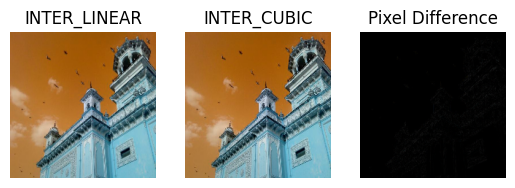

In [6]:
import matplotlib.pyplot as plt
titles = ["INTER_LINEAR", "INTER_CUBIC", "Pixel Difference"]
images = [inter_linear,inter_cubic, diff]

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.show()

(<Axes: title={'center': '90°'}>,
 Text(0.5, 1.0, '90°'),
 (np.float64(-0.5), np.float64(383.5), np.float64(511.5), np.float64(-0.5)))

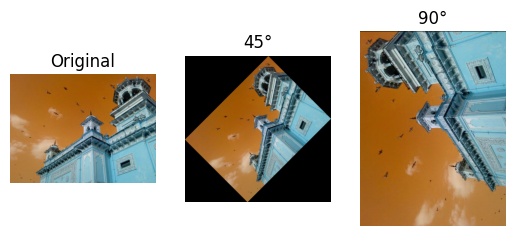

In [7]:
#3
h, w = img.shape[:2]

def rotate(img, angle):
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
    cos, sin = abs(M[0,0]), abs(M[0,1])

    nw = int(h*sin + w*cos)
    nh = int(h*cos + w*sin)

    M[0,2] += nw/2 - w/2
    M[1,2] += nh/2 - h/2

    return cv2.warpAffine(img, M, (nw, nh))

r45 = rotate(img, 45)
r90 = rotate(img, 90)

plt.subplot(131), plt.imshow(img), plt.title("Original"), plt.axis("off")
plt.subplot(132), plt.imshow(r45), plt.title("45°"), plt.axis("off")
plt.subplot(133), plt.imshow(r90), plt.title("90°"), plt.axis("off")

In [ ]:
#4
# ROI Crop
roi = img[100:300, 150:350]

# Horizontal and Vertical Flip
h_flip = cv2.flip(roi, 1)
v_flip = cv2.flip(roi, 0)

cv2.imshow("gray Image", v_flip)
cv2.waitKey(0)       
cv2.destroyAllWindows()



In [ ]:

cv2.imshow("gray Image", h_flip)
cv2.waitKey(0)       
cv2.destroyAllWindows()

In [10]:
# 5
# BGR to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# BGR to HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

In [13]:
cv2.imshow("gray Image", gray)
cv2.waitKey(0)       
cv2.destroyAllWindows()

In [14]:
cv2.imshow("My First Image", hsv)
cv2.waitKey(0)       
cv2.destroyAllWindows()